# cloudposterior: Monitoring

Monitor MCMC sampling remotely with a live dashboard or push notifications.

- **`dashboard=True`** (default for remote) -- live web dashboard with convergence diagnostics, trace plots, and a stop button. Open on your phone or any browser via QR code.
- **`notify=True`** -- push notifications via [ntfy](https://ntfy.sh) when sampling starts and completes.

> Run this notebook locally to see the QR codes and links.

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

import cloudposterior as cp

In [2]:
df = pd.read_csv(pm.get_data("radon.csv"))

with pm.Model(name="radon_intercepts", coords={"county": df.county.unique()}) as radon:
    mu_a = pm.Normal("mu_a", mu=0, sigma=5)
    sigma_a = pm.HalfNormal("sigma_a", sigma=2)
    a_raw = pm.Normal("a_raw", mu=0, sigma=1, dims="county")
    a = pm.Deterministic("a", mu_a + sigma_a * a_raw, dims="county")
    b_floor = pm.Normal("b_floor", mu=0, sigma=5)
    mu = a[df.county_code.values] + b_floor * df.floor.values
    sigma_y = pm.HalfNormal("sigma_y", sigma=2)
    pm.Normal("obs", mu=mu, sigma=sigma_y, observed=df.log_radon.values)

## Live dashboard

The dashboard is on by default for remote runs. Scan the QR code or open the URL to see:

- Per-chain progress bars with speed, divergences, and ETA
- Live convergence diagnostics (R-hat, ESS) with color-coded status
- Live trace plots and posterior KDE per parameter
- A stop button to end sampling early if convergence looks good

In [3]:
with cp.cloud(radon, remote=True, cache=False):
    idata = pm.sample(draws=10000, tune=1000, chains=4)

In [4]:
az.summary(idata, filter_vars="like", var_names=["mu_a", "sigma_a", "b_floor", "sigma_y"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
radon_intercepts::mu_a,1.493,0.050,1.396,1.584,0.001,0.000,6989.0,9609.0,1.0
radon_intercepts::b_floor,-0.663,0.068,-0.797,-0.544,0.001,0.001,16546.0,12346.0,1.0
radon_intercepts::sigma_a,0.321,0.045,0.241,0.407,0.001,0.000,4614.0,6127.0,1.0
radon_intercepts::sigma_y,0.727,0.018,0.693,0.760,0.000,0.000,15069.0,10325.0,1.0


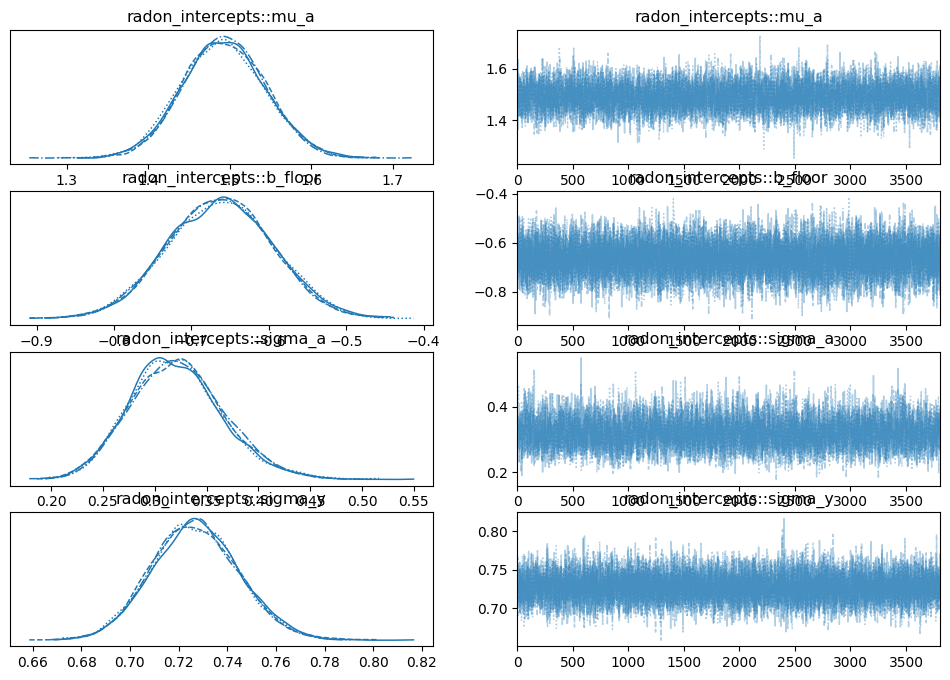

In [5]:
az.plot_trace(idata, filter_vars="like", var_names=["mu_a", "sigma_a", "b_floor", "sigma_y"]);

## Push notifications

Pass `notify=True` to get push notifications when sampling starts and completes. Works for both local and remote runs. Scan the QR code with the [ntfy app](https://ntfy.sh) to subscribe.

For private notifications, point to your own [ntfy server](https://docs.ntfy.sh/install/) with `notify={"server": "https://ntfy.example.com"}`.

In [6]:
with cp.cloud(radon, cache=False, notify=True):
    idata = pm.sample(draws=2000, tune=1000, chains=4)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [radon_intercepts::mu_a, radon_intercepts::sigma_a, radon_intercepts::a_raw, radon_intercepts::b_floor, radon_intercepts::sigma_y]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


## Both

Use both together to get the live dashboard AND push notifications.

In [7]:
with cp.cloud(radon, remote=True, cache=False, notify=True):
    idata = pm.sample(draws=1000, tune=1000, chains=4)